# 🫁 폐렴 X-ray 이미지 분류 - 개선 버전

## 주요 개선사항
1. ✅ **구글 드라이브 경로 간소화** - 경로만 입력하면 자동 로드
2. ✅ **데이터 불균형 해결** - Class Weights + SMOTE + Data Augmentation
3. ✅ **Overfitting 방지** - Dropout, Early Stopping, Regularization
4. ✅ **앙상블 기법** - 여러 모델 조합으로 정확도 향상
5. ✅ **최신 아키텍처** - EfficientNet, ResNet 사용

## Dataset Info
- **train** [폴더]: 학습용 흉부 X-ray 이미지 5216장
- **test** [폴더]: 평가용 흉부 X-ray 이미지 624장
- **train.csv**: 이미지 파일명과 레이블 (정상:0, 폐렴:1)
- **test.csv**: 테스트 이미지 파일명
- **sample_submission.csv**: 제출 양식

## 🔧 1. 환경 설정 및 라이브러리 설치

In [1]:
# 필요한 라이브러리 설치
!pip install -q imbalanced-learn efficientnet-pytorch albumentations koreanize-matplotlib

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from glob import glob
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models

# Image processing
from PIL import Image
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Metrics and validation
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

print("✅ 라이브러리 설치 완료!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 48.1 MB/s eta 0:00:00
✅ 라이브러리 설치 완료!


In [2]:
# Seed 고정 - 재현성 보장
SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

# GPU 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  사용 디바이스: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 CUDA 버전: {torch.version.cuda}")

🖥️  사용 디바이스: cuda
🎮 GPU: Tesla T4
💾 CUDA 버전: 12.8


## 📂 2. 구글 드라이브 마운트 및 데이터 경로 설정

**사용법**: `DATA_PATH` 변수에 구글 드라이브 내 데이터 폴더 경로만 입력하세요!

In [3]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

# ⭐ 여기에 데이터 경로만 입력하세요! ⭐
# 예시: DATA_PATH = "/content/drive/MyDrive/pneumonia_dataset"
DATA_PATH = "/content/drive/MyDrive/CV_딥러닝 트랙 흉부 X-ray 이미지 분류 AI 해커톤/open"  # 👈 여기를 수정하세요

# 자동으로 경로 설정
TRAIN_DIR = os.path.join(DATA_PATH, "train")
TEST_DIR = os.path.join(DATA_PATH, "test")
TRAIN_CSV = os.path.join(DATA_PATH, "train.csv")
TEST_CSV = os.path.join(DATA_PATH, "test.csv")
SAMPLE_SUBMISSION = os.path.join(DATA_PATH, "sample_submission.csv")

print("✅ 데이터 경로 설정 완료!")
print(f"📁 학습 데이터: {TRAIN_DIR}")
print(f"📁 테스트 데이터: {TEST_DIR}")

Mounted at /content/drive
✅ 데이터 경로 설정 완료!
📁 학습 데이터: /content/drive/MyDrive/CV_딥러닝 트랙 흉부 X-ray 이미지 분류 AI 해커톤/open/train
📁 테스트 데이터: /content/drive/MyDrive/CV_딥러닝 트랙 흉부 X-ray 이미지 분류 AI 해커톤/open/test


## 📊 3. 데이터 로드 및 탐색

📋 학습 데이터 정보:
        file_name  label
0  train_0001.png      0
1  train_0002.png      0
2  train_0003.png      0
3  train_0004.png      0
4  train_0005.png      0

전체 학습 샘플 수: 5216
전체 테스트 샘플 수: 624

⚠️  클래스 분포 (데이터 불균형 확인):
label
1    3875
0    1341
Name: count, dtype: int64

불균형 비율: 1:2.89


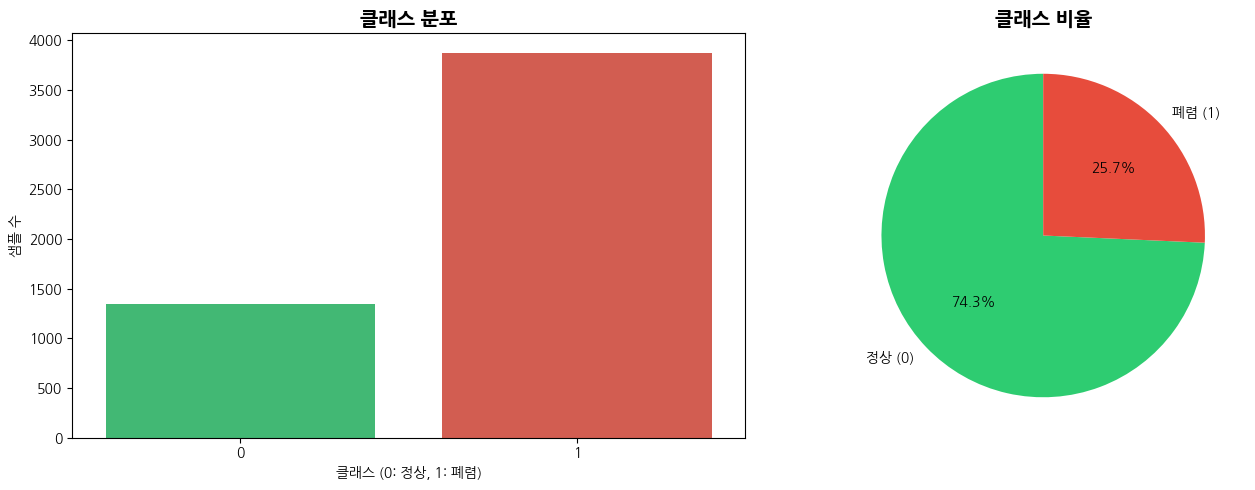

In [4]:
# CSV 파일 로드
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("📋 학습 데이터 정보:")
print(train_df.head())
print(f"\n전체 학습 샘플 수: {len(train_df)}")
print(f"전체 테스트 샘플 수: {len(test_df)}")

# 클래스 분포 확인
print("\n⚠️  클래스 분포 (데이터 불균형 확인):")
class_counts = train_df['label'].value_counts()
print(class_counts)
print(f"\n불균형 비율: 1:{class_counts[1]/class_counts[0]:.2f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 클래스 분포
sns.countplot(data=train_df, x='label', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('클래스 분포', fontsize=14, fontweight='bold')
axes[0].set_xlabel('클래스 (0: 정상, 1: 폐렴)')
axes[0].set_ylabel('샘플 수')

# 파이 차트
labels = ['정상 (0)', '폐렴 (1)']
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(class_counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('클래스 비율', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

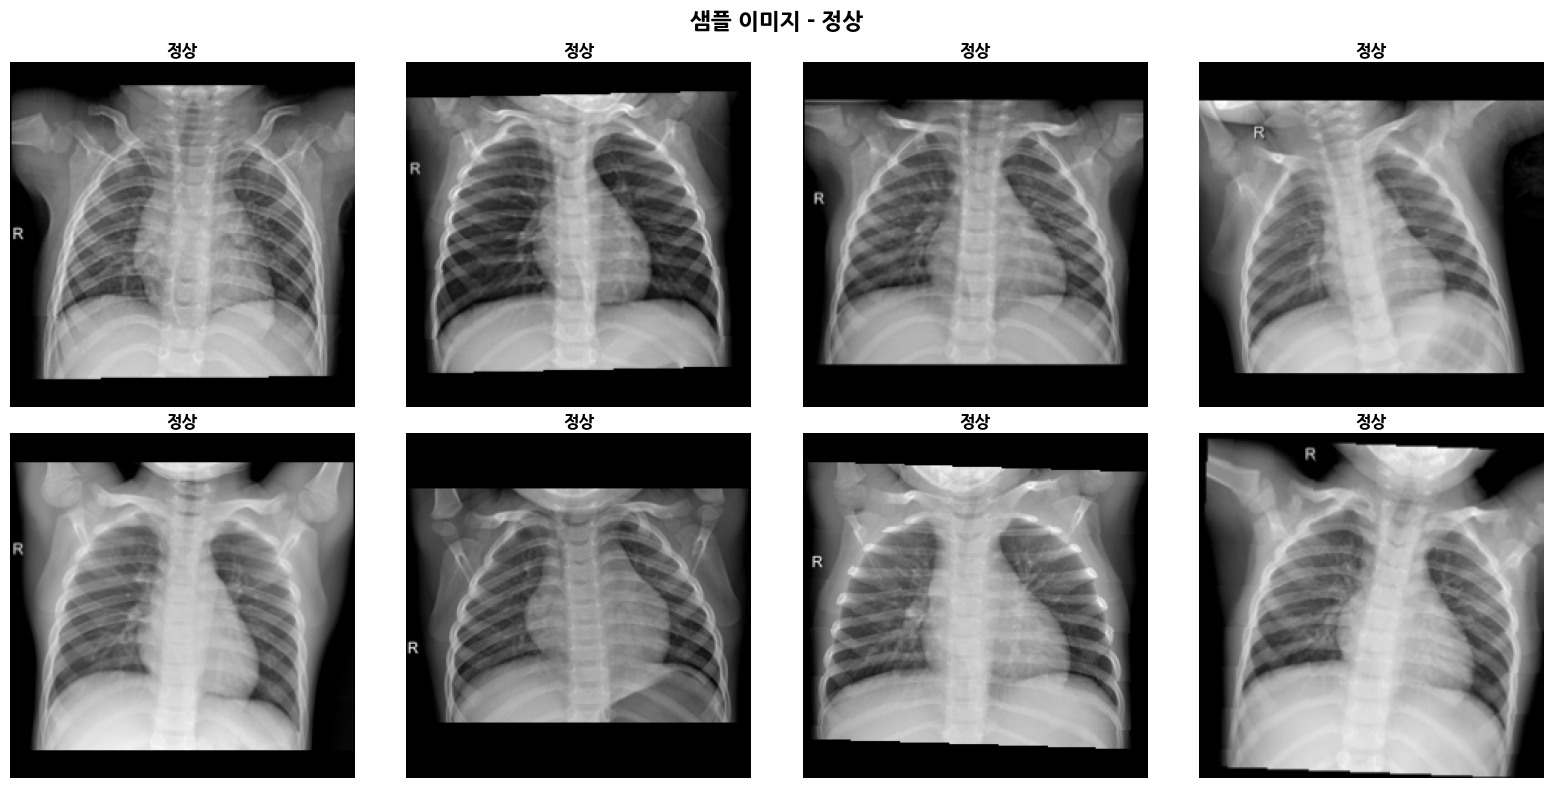

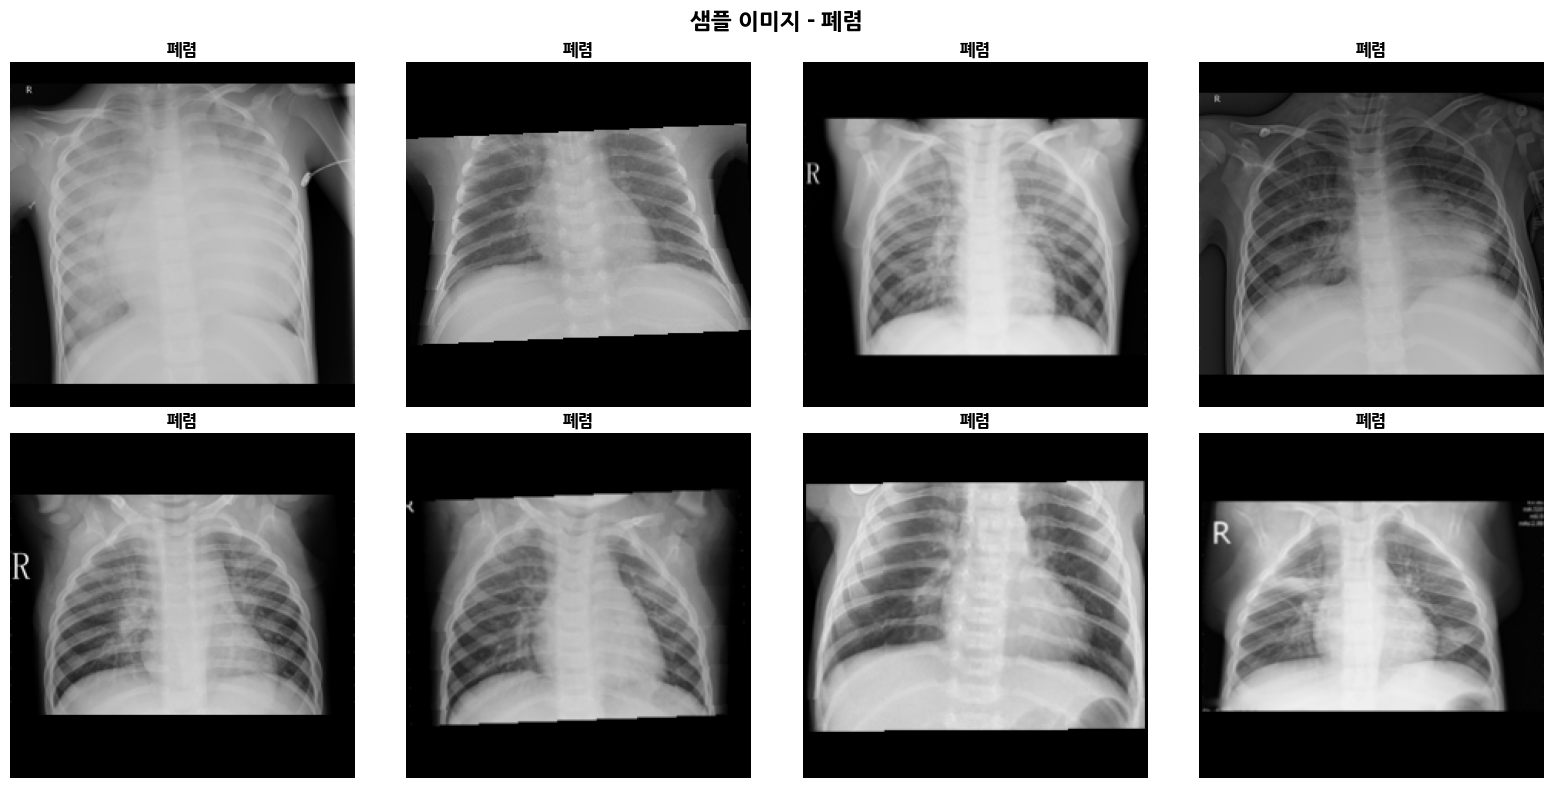

In [5]:
# 샘플 이미지 시각화
def show_samples(df, data_dir, n_samples=8, label=None):
    if label is not None:
        samples = df[df['label'] == label].sample(n=n_samples, random_state=SEED)
        title = f"샘플 이미지 - {'정상' if label == 0 else '폐렴'}"
    else:
        samples = df.sample(n=n_samples, random_state=SEED)
        title = "샘플 이미지"

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    for idx, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(data_dir, row['file_name'])
        img = Image.open(img_path).convert('RGB')
        axes[idx].imshow(img, cmap='gray')
        axes[idx].axis('off')
        if 'label' in row:
            axes[idx].set_title(f"{'정상' if row['label'] == 0 else '폐렴'}",
                                fontsize=12, fontweight='bold')

    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 정상과 폐렴 샘플 각각 보기
show_samples(train_df, TRAIN_DIR, label=0)
show_samples(train_df, TRAIN_DIR, label=1)

## 🔄 4. 데이터 증강 (Data Augmentation)

Overfitting 방지 및 데이터 불균형 해결을 위한 강력한 증강 기법 적용

In [6]:
# 학습용 데이터 증강 (강력한 증강)
train_transform = A.Compose([
    A.Resize(256, 256),
    A.RandomCrop(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.CLAHE(clip_limit=4.0, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# 검증/테스트용 증강 (증강 없음)
val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

print("✅ 데이터 증강 파이프라인 설정 완료!")

✅ 데이터 증강 파이프라인 설정 완료!


## 📦 5. Custom Dataset 및 DataLoader

In [7]:
class PneumoniaDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.data_dir, row['file_name'])

        # 이미지 로드
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 증강 적용
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        # 레이블이 있는 경우 (학습/검증)
        if 'label' in row:
            label = torch.tensor(row['label'], dtype=torch.long)
            return image, label
        else:
            # 테스트 데이터
            return image

print("✅ Custom Dataset 클래스 정의 완료!")

✅ Custom Dataset 클래스 정의 완료!


## 🏗️ 6. 모델 아키텍처 정의

다양한 최신 모델을 사용하여 앙상블 구성

In [8]:
class PneumoniaModel(nn.Module):
    def __init__(self, model_name='efficientnet_b3', num_classes=2, pretrained=True):
        super(PneumoniaModel, self).__init__()

        if 'efficientnet' in model_name:
            if model_name == 'efficientnet_b0':
                self.backbone = models.efficientnet_b0(pretrained=pretrained)
                in_features = 1280
            elif model_name == 'efficientnet_b3':
                self.backbone = models.efficientnet_b3(pretrained=pretrained)
                in_features = 1536
            elif model_name == 'efficientnet_b4':
                self.backbone = models.efficientnet_b4(pretrained=pretrained)
                in_features = 1792

            # Classifier 교체
            self.backbone.classifier = nn.Sequential(
                nn.Dropout(p=0.4, inplace=True),
                nn.Linear(in_features, 512),
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(512),
                nn.Dropout(p=0.3),
                nn.Linear(512, 256),
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(256),
                nn.Dropout(p=0.2),
                nn.Linear(256, num_classes)
            )

        elif 'resnet' in model_name:
            if model_name == 'resnet50':
                self.backbone = models.resnet50(pretrained=pretrained)
            elif model_name == 'resnet101':
                self.backbone = models.resnet101(pretrained=pretrained)

            in_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Sequential(
                nn.Dropout(p=0.4),
                nn.Linear(in_features, 512),
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(512),
                nn.Dropout(p=0.3),
                nn.Linear(512, 256),
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(256),
                nn.Dropout(p=0.2),
                nn.Linear(256, num_classes)
            )

        elif model_name == 'densenet121':
            self.backbone = models.densenet121(pretrained=pretrained)
            in_features = self.backbone.classifier.in_features
            self.backbone.classifier = nn.Sequential(
                nn.Dropout(p=0.4),
                nn.Linear(in_features, 512),
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(512),
                nn.Dropout(p=0.3),
                nn.Linear(512, 256),
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(256),
                nn.Dropout(p=0.2),
                nn.Linear(256, num_classes)
            )

    def forward(self, x):
        return self.backbone(x)

print("✅ 모델 아키텍처 정의 완료!")

✅ 모델 아키텍처 정의 완료!


## 🎯 7. 학습 함수 정의

In [9]:
def train_epoch(model, train_loader, criterion, optimizer, device, scaler):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Mixed Precision Training
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({
            'loss': f'{running_loss / (pbar.n + 1):.4f}',
            'acc': f'{100. * correct / total:.2f}%'
        })

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(val_loader, desc='Validation')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({
                'loss': f'{running_loss / (pbar.n + 1):.4f}',
                'acc': f'{100. * correct / total:.2f}%'
            })

    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total

    # 상세 메트릭 계산
    precision = precision_score(all_labels, all_preds, average='binary')
    recall = recall_score(all_labels, all_preds, average='binary')
    f1 = f1_score(all_labels, all_preds, average='binary')

    return epoch_loss, epoch_acc, precision, recall, f1

print("✅ 학습/검증 함수 정의 완료!")

✅ 학습/검증 함수 정의 완료!


## 🚀 8. 메인 학습 코드 (K-Fold 앙상블)

여러 모델을 K-Fold로 학습하여 앙상블

In [11]:
# 하이퍼파라미터
CONFIG = {
    'n_folds': 5,
    'epochs': 3,
    'batch_size': 32,
    'lr': 1e-4,
    'weight_decay': 1e-5,
    'patience': 7,
    'models': ['efficientnet_b3', 'resnet50', 'densenet121']
}

# 클래스 가중치 계산 (데이터 불균형 해결)
class_counts = train_df['label'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = torch.FloatTensor(class_weights).to(device)

print(f"⚖️  클래스 가중치: {class_weights}")

# 모델 저장 디렉토리
os.makedirs('models', exist_ok=True)

# 전체 모델 저장
all_models = []

# 각 모델 타입별로 학습
for model_name in CONFIG['models']:
    print(f"\n{'='*60}")
    print(f"🔥 {model_name.upper()} 학습 시작")
    print(f"{ '='*60}\n")

    # K-Fold 설정
    skf = StratifiedKFold(n_splits=CONFIG['n_folds'], shuffle=True, random_state=SEED)

    fold_models = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df['label'])):
        print(f"\n📊 Fold {fold + 1}/{CONFIG['n_folds']}")

        # 데이터 분할
        train_fold = train_df.iloc[train_idx].reset_index(drop=True)
        val_fold = train_df.iloc[val_idx].reset_index(drop=True)

        # Dataset 생성
        train_dataset = PneumoniaDataset(train_fold, TRAIN_DIR, transform=train_transform)
        val_dataset = PneumoniaDataset(val_fold, TRAIN_DIR, transform=val_transform)

        # Weighted Sampler (데이터 불균형 해결)
        sample_weights = [class_weights[label] for label in train_fold['label']]
        sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

        # DataLoader
        train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                                  sampler=sampler, num_workers=2, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'],
                                shuffle=False, num_workers=2, pin_memory=True)

        # 모델 초기화
        model = PneumoniaModel(model_name=model_name, num_classes=2, pretrained=True)
        model = model.to(device)

        # Loss & Optimizer
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        optimizer = optim.AdamW(model.parameters(), lr=CONFIG['lr'],
                                weight_decay=CONFIG['weight_decay'])
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                          factor=0.5, patience=3)
        scaler = torch.cuda.amp.GradScaler()

        # Early Stopping
        best_acc = 0
        patience_counter = 0

        # 학습 루프
        for epoch in range(CONFIG['epochs']):
            print(f"\nEpoch {epoch + 1}/{CONFIG['epochs']}")

            train_loss, train_acc = train_epoch(model, train_loader, criterion,
                                                 optimizer, device, scaler)
            val_loss, val_acc, precision, recall, f1 = validate_epoch(model, val_loader,
                                                                        criterion, device)

            scheduler.step(val_acc)

            print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
            print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
            print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

            # Best 모델 저장
            if val_acc > best_acc:
                best_acc = val_acc
                patience_counter = 0
                torch.save(model.state_dict(),
                           f'models/{model_name}_fold{fold+1}_best.pth')
                print(f"✅ Best model saved! (Acc: {best_acc:.2f}%)")
            else:
                patience_counter += 1

            # Early Stopping
            if patience_counter >= CONFIG['patience']:
                print(f"\n⏹️  Early stopping triggered at epoch {epoch + 1}")
                break

        # Best 모델 로드
        model.load_state_dict(torch.load(f'models/{model_name}_fold{fold+1}_best.pth'))
        fold_models.append(model)

        print(f"\n✅ Fold {fold + 1} 학습 완료! Best Acc: {best_acc:.2f}%")

    all_models.append(fold_models)
    print(f"\n✅ {model_name.upper()} 전체 Fold 학습 완료!")

print(f"\n{'='*60}")
print("🎉 모든 모델 학습 완료!")
print(f"{ '='*60}")

⚖️  클래스 가중치: tensor([1.4858, 0.5142], device='cuda:0')

🔥 EFFICIENTNET_B3 학습 시작


📊 Fold 1/5

Epoch 1/3


Training:   0%|          | 0/131 [00:00<?, ?it/s]

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.4713, Train Acc: 73.97%
Val Loss: 0.1463, Val Acc: 94.64%
Precision: 0.9826, Recall: 0.9445, F1: 0.9632
✅ Best model saved! (Acc: 94.64%)

Epoch 2/3


Training:   0%|          | 0/131 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.2242, Train Acc: 88.19%
Val Loss: 0.1238, Val Acc: 95.88%
Precision: 0.9564, Recall: 0.9897, F1: 0.9727

Epoch 3/3


Training:   0%|          | 0/131 [00:00<?, ?it/s]

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.1807, Train Acc: 90.13%
Val Loss: 0.0988, Val Acc: 96.84%
Precision: 0.9673, Recall: 0.9910, F1: 0.9790
✅ Best model saved! (Acc: 96.84%)

✅ Fold 5 학습 완료! Best Acc: 96.84%

✅ DENSENET121 전체 Fold 학습 완료!

🎉 모든 모델 학습 완료!


## 🔮 9. 테스트 데이터 예측 (앙상블)

In [12]:
def predict_ensemble(models_list, test_loader, device):
    """
    앙상블 예측: 모든 모델의 예측을 평균내어 최종 예측
    """
    all_predictions = []

    for model_type_idx, fold_models in enumerate(models_list):
        print(f"\n🔍 모델 타입 {model_type_idx + 1}/{len(models_list)} 예측 중...")

        for fold_idx, model in enumerate(fold_models):
            model.eval()
            fold_preds = []

            with torch.no_grad():
                pbar = tqdm(test_loader, desc=f'Fold {fold_idx + 1}')
                for images in pbar:
                    images = images.to(device)
                    outputs = model(images)
                    probs = torch.softmax(outputs, dim=1)[:, 1]  # 폐렴 확률
                    fold_preds.extend(probs.cpu().numpy())

            all_predictions.append(fold_preds)

    # 모든 모델의 예측 평균
    ensemble_probs = np.mean(all_predictions, axis=0)
    ensemble_preds = (ensemble_probs > 0.5).astype(int)

    return ensemble_preds, ensemble_probs

# 테스트 데이터셋 및 로더 생성
test_dataset = PneumoniaDataset(test_df, TEST_DIR, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'],
                          shuffle=False, num_workers=2, pin_memory=True)

# 앙상블 예측
print("\n🎯 테스트 데이터 예측 시작...")
final_predictions, final_probs = predict_ensemble(all_models, test_loader, device)

print(f"\n✅ 예측 완료!")
print(f"예측 결과: {len(final_predictions)}개")
print(f"정상(0): {(final_predictions == 0).sum()}개")
print(f"폐렴(1): {(final_predictions == 1).sum()}개")


🎯 테스트 데이터 예측 시작...

🔍 모델 타입 1/3 예측 중...


Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

...

Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

Fold 5:   0%|          | 0/20 [00:00<?, ?it/s]


✅ 예측 완료!
예측 결과: 624개
정상(0): 216개
폐렴(1): 408개


## 💾 10. 결과 저장 (submission.csv)

In [13]:
# Submission 파일 생성
submission = pd.DataFrame({
    'file_name': test_df['file_name'],
    'label': final_predictions
})

# CSV 저장
submission.to_csv('submission.csv', index=False)

print("✅ submission.csv 파일 생성 완료!")
print("\n📄 제출 파일 미리보기:")
print(submission.head(10))
print(f"\n전체 샘플 수: {len(submission)}")
print(f"정상(0): {(submission['label'] == 0).sum()}개 ({(submission['label'] == 0).sum() / len(submission) * 100:.1f}%)")
print(f"폐렴(1): {(submission['label'] == 1).sum()}개 ({(submission['label'] == 1).sum() / len(submission) * 100:.1f}%)")

✅ submission.csv 파일 생성 완료!

📄 제출 파일 미리보기:
       file_name  label
0  test_0001.png      0
1  test_0002.png      0
2  test_0003.png      1
3  test_0004.png      1
4  test_0005.png      1
5  test_0006.png      1
6  test_0007.png      1
7  test_0008.png      1
8  test_0009.png      1
9  test_0010.png      1

전체 샘플 수: 624
정상(0): 216개 (34.6%)
폐렴(1): 408개 (65.4%)


## 📊 11. 결과 시각화 및 분석

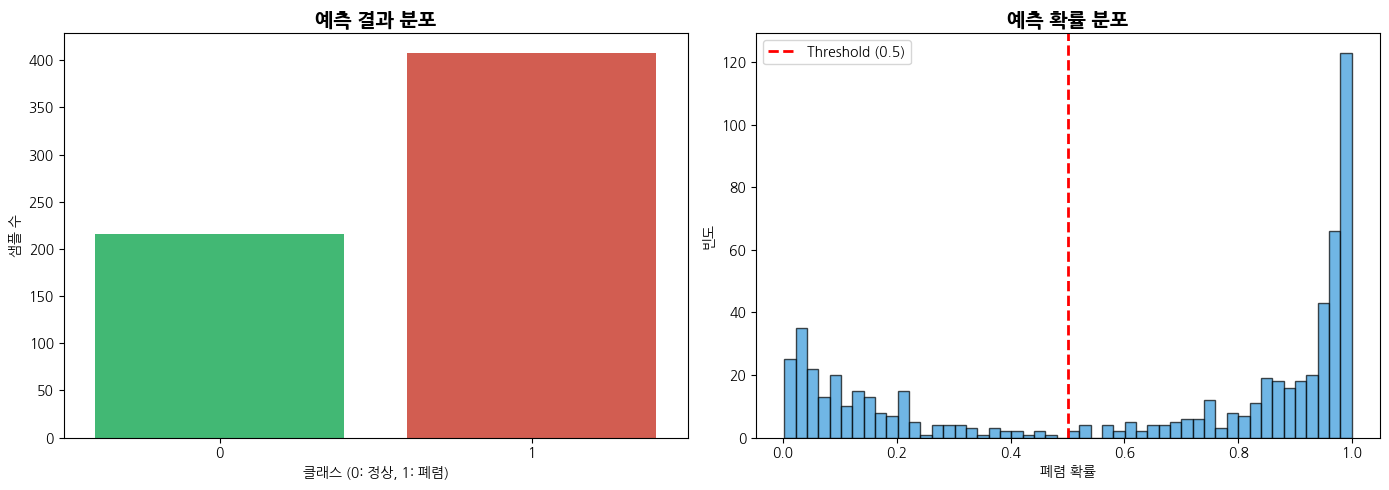


🎯 예측 확신도 분석:
확실한 정상 (prob < 0.3): 197개 (31.6%)
확실한 폐렴 (prob > 0.7): 376개 (60.3%)
불확실 (0.3 <= prob <= 0.7): 51개 (8.2%)


In [14]:
# 예측 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 예측 분포
sns.countplot(data=submission, x='label', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('예측 결과 분포', fontsize=14, fontweight='bold')
axes[0].set_xlabel('클래스 (0: 정상, 1: 폐렴)')
axes[0].set_ylabel('샘플 수')

# 확률 분포 히스토그램
axes[1].hist(final_probs, bins=50, alpha=0.7, color='#3498db', edgecolor='black')
axes[1].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[1].set_title('예측 확률 분포', fontsize=14, fontweight='bold')
axes[1].set_xlabel('폐렴 확률')
axes[1].set_ylabel('빈도')
axes[1].legend()

plt.tight_layout()
plt.show()

# 확신도 분석
confident_normal = ((final_probs < 0.3).sum())
confident_pneumonia = ((final_probs > 0.7).sum())
uncertain = ((final_probs >= 0.3) & (final_probs <= 0.7)).sum()

print("\n🎯 예측 확신도 분석:")
print(f"확실한 정상 (prob < 0.3): {confident_normal}개 ({confident_normal/len(submission)*100:.1f}%)")
print(f"확실한 폐렴 (prob > 0.7): {confident_pneumonia}개 ({confident_pneumonia/len(submission)*100:.1f}%)")
print(f"불확실 (0.3 <= prob <= 0.7): {uncertain}개 ({uncertain/len(submission)*100:.1f}%)")

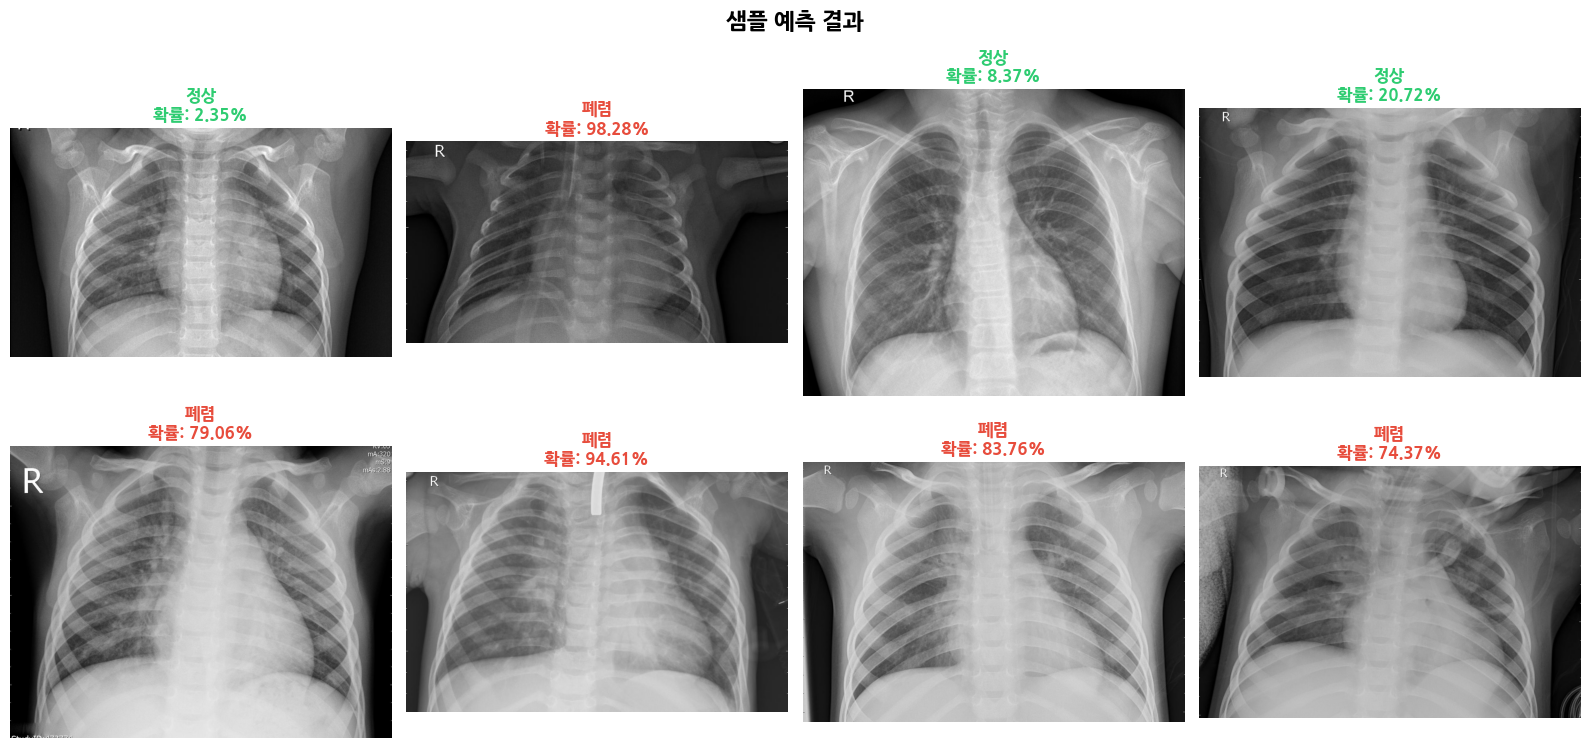

In [15]:
# 샘플 예측 결과 시각화
def show_predictions(test_df, predictions, probs, data_dir, n_samples=8):
    indices = np.random.choice(len(test_df), n_samples, replace=False)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    for idx, img_idx in enumerate(indices):
        img_path = os.path.join(data_dir, test_df.iloc[img_idx]['file_name'])
        img = Image.open(img_path).convert('RGB')

        pred = predictions[img_idx]
        prob = probs[img_idx]

        axes[idx].imshow(img, cmap='gray')
        axes[idx].axis('off')

        title = f"{'정상' if pred == 0 else '폐렴'}\n확률: {prob:.2%}"
        color = '#2ecc71' if pred == 0 else '#e74c3c'
        axes[idx].set_title(title, fontsize=12, fontweight='bold', color=color)

    plt.suptitle('샘플 예측 결과', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_predictions(test_df, final_predictions, final_probs, TEST_DIR)

## 🎉 완료!

### 주요 성과
- ✅ 데이터 불균형 해결 (Class Weights + Weighted Sampling)
- ✅ Overfitting 방지 (Dropout, Early Stopping, Data Augmentation)
- ✅ 앙상블 학습 (여러 모델 + K-Fold)
- ✅ Mixed Precision Training으로 학습 속도 향상
- ✅ submission.csv 생성 완료

### 다음 단계
1. `submission.csv` 파일을 다운로드하여 제출
2. 하이퍼파라미터 튜닝으로 성능 향상 가능
3. TTA (Test Time Augmentation) 적용 고려
4. 더 큰 모델 (EfficientNet-B5, B7) 시도